# Optical Networking Gym: An Open-Source Toolkit for Resource Assignment Problems in Optical Networks

File processing the results of the experiments.

In [1]:
import itertools
import os
import pickle

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# plt.rcParams.get("font.size")
plt.rcParams.update({'font.size': 14})

In [3]:
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

topology_name = "nobel-eu"
# topology_name = "janos-us"
# topology_name = "germany50"
strategies = [1]#np.arange(1, 5)

launch_powers = np.linspace(-8, 8, 9)

if topology_name == "nobel-eu":
    load = 210.0
    loads = np.arange(50, 651, 50)
elif topology_name == "germany50":
    load = 400.0
    loads = np.arange(300, 801, 50)
elif topology_name == "janos-us":
    load = 150.0
    loads = np.arange(100, 601, 50)

bandwidth = 4e12
frequency_start = 3e8 / 1565e-9
frequency_end = frequency_start + bandwidth
frequency_slot_bandwidth = 12.5e9
bit_rates = np.array((10, 40, 100, 400), dtype=np.int16)

markers = ("o", ">", "s", "<", "^", "v")
heuristics = ["KSP-FF-BM", "LS-BM-KSP", "BM-KSP-LB", "KSP-LB-BM"]

## Plots for the topology

In [99]:
# with open(
#     os.path.join(
#         "..",
#         # "examples", 
#         "topologies", f"{topology_name}.xml"
#         # "examples", "topologies", "nobel-us_gn_5-paths_6-modulations.h5"
#         # "examples", "topologies", "nobel-eu_gn_5-paths_6-modulations.h5"
#         # "examples", "topologies", "janos-us_gn_5-paths_6-modulations.h5"
#         # "examples", "topologies", "nsfnet_chen_gn_5-paths_6-modulations.h5"
#     ), "rb"
# ) as f:
#     topology = pickle.load(f)
from typing import Tuple
from optical_networking_gym.topology import Modulation, get_topology

topology_path = os.path.join(
        "..",
        # "examples", 
        "topologies", f"{topology_name}_5-paths_6-modulations.h5"
        # "examples", "topologies", "nobel-us_gn_5-paths_6-modulations.h5"
        # "examples", "topologies", "nobel-eu_gn_5-paths_6-modulations.h5"
        # "examples", "topologies", "janos-us_gn_5-paths_6-modulations.h5"
        # "examples", "topologies", "nsfnet_chen_gn_5-paths_6-modulations.h5"
    ), "rb"
) as f:
    topology = pickle.load(f)

In [100]:
print("nodes:", topology.number_of_nodes(), topology.number_of_nodes()*(topology.number_of_nodes()-1) // 2)
print("edges:", topology.number_of_edges())

nodes: 28 378
edges: 41


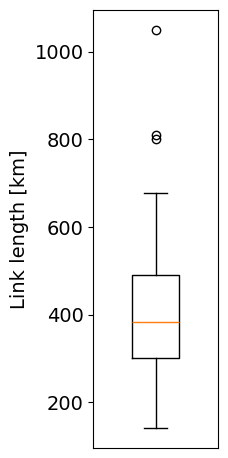

In [101]:
plt.figure(figsize=(2.5, 4.8))
plt.boxplot([topology[x][y]["length"] for x, y in topology.edges()])
plt.ylabel("Link length [km]")
plt.xticks([], [])
plt.xlim([0.8, 1.2])
plt.tight_layout()
# plt.savefig(f"figures/{topology_name}_topo_link_length.png")
# plt.savefig(f"figures/{topology_name}_topo_link_length.pdf")
# plt.savefig(f"figures/{topology_name}_topo_link_length.svg")
plt.show()

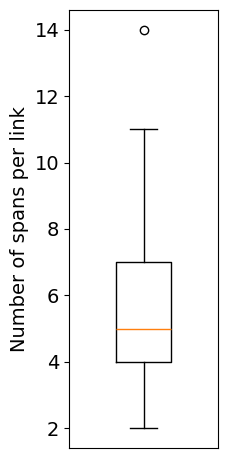

In [102]:
plt.figure(figsize=(2.5, 4.8))
plt.boxplot([len(topology[x][y]["link"].spans) for x, y in topology.edges()])
plt.ylabel("Number of spans per link")
plt.xticks([], [])
plt.xlim([0.8, 1.2])
plt.tight_layout()
plt.savefig(f"figures/{topology_name}_topo_link_spans.png")
plt.savefig(f"figures/{topology_name}_topo_link_spans.pdf")
# plt.savefig(f"figures/{topology_name}_topo_link_spans.svg")
plt.show()

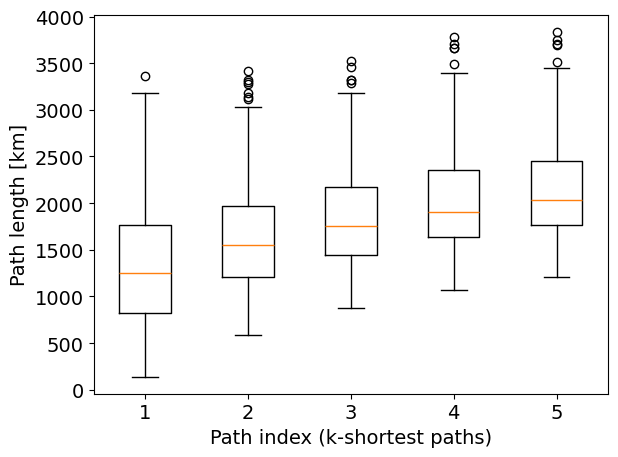

In [103]:
path_lengths = []
for k in range(topology.graph["k_paths"]):
    path_lengths.append([topology.graph["ksp"][x, y][k].length for x, y in itertools.combinations(topology.nodes(), 2)])
plt.figure()
plt.boxplot(path_lengths)
plt.xlabel("Path index (k-shortest paths)")
plt.ylabel("Path length [km]")
plt.tight_layout()
# plt.savefig(f"figures/{topology_name}_topo_path_length.png")
# plt.savefig(f"figures/{topology_name}_topo_path_length.pdf")
# plt.savefig(f"figures/{topology_name}_topo_path_length.svg")
plt.show()

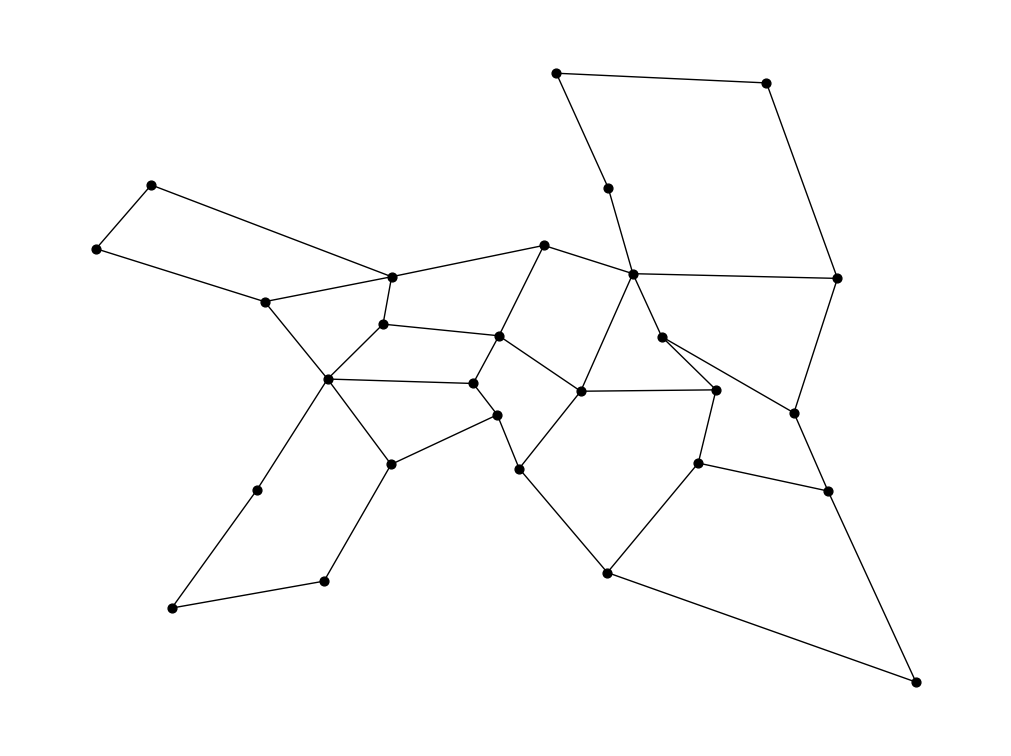

In [104]:
pos = nx.get_node_attributes(topology, "pos")
labels = {x: f"{y:.0f}" for x, y in nx.get_edge_attributes(topology, "length").items()}
plt.figure(figsize=(12.8, 9.6))

nx.draw_networkx_nodes(topology, pos=pos, node_color="black", node_size=40)
# nx.draw_networkx_labels(topology, pos={x: (y[0], y[1]-0.5) for x, y in pos.items()}, labels={x: x for x in topology.nodes()}, font_color="blue")

nx.draw_networkx_edges(topology, pos=pos)
# nx.draw_networkx_edge_labels(topology, pos=pos, edge_labels=labels, font_size=12, rotate=False)
plt.axis('off')
plt.gca().set_aspect("equal", adjustable="box")
plt.savefig(f"figures/{topology_name}_topo.png")
plt.savefig(f"figures/{topology_name}_topo.pdf")
# plt.savefig(f"figures/{topology_name}_topo.svg")
plt.show()

## Plots for the launch power

In [4]:
means = []
stdevs = []
topology_name = "nobel-eu"
load = 210.0
launch_powers = np.linspace(-8, 8, 17)
for launch_power in launch_powers:
    data_episodes = pd.read_csv(f"results/simulation_updteded_th_results_{topology_name}_{launch_power}_{load}.csv", skiprows=1)
    means.append(data_episodes["episode_service_blocking_rate"].mean())
    stdevs.append(data_episodes["episode_service_blocking_rate"].std())

plt.figure()
plt.errorbar(launch_powers, means, stdevs)
plt.gca().set_yscale("log")
plt.grid(visible=True, which="major", axis="y", ls="--")
# plt.grid(visible=True, which="major", axis="x", ls=":")
plt.grid(visible=True, which="minor", axis="y", ls=":")
plt.xlabel("Launch power [dBm]")
plt.ylabel("Request blocking ratio")
plt.xticks(range(-8, 9, 2))
plt.tight_layout()
# plt.savefig(f"figures/{topology_name}_lp_rbr.png")
# plt.savefig(f"figures/{topology_name}_lp_rbr.pdf")
# plt.savefig(f"figures/{topology_name}_lp_rbr.svg")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'results/simulation_updteded_th_results_nobel-eu_-8.0_210.0.csv'

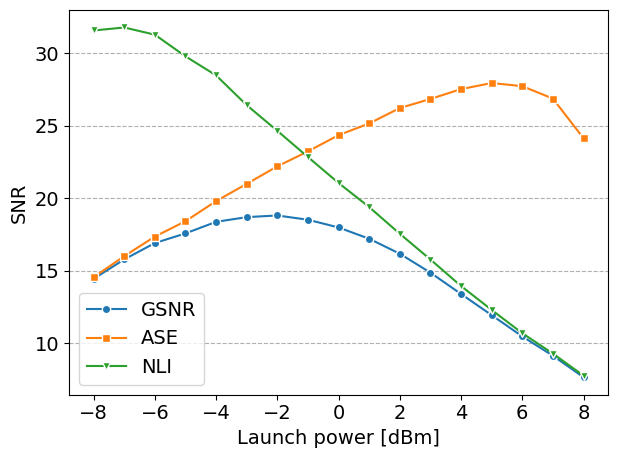

In [9]:
mean_osnr = []
stdev_osnr = []
mean_ase = []
stdev_ase = []
mean_nli = []
stdev_nli = []
disrupted_services = []
best_launch_power = 0
best_mean = 0

for launch_power in launch_powers:
    data_services = pd.read_csv(f"results/lp_services_1_{topology_name}_{launch_power}_{load}_20.csv", skiprows=1)

    mean = data_services["osnr"].mean()

    if mean > best_mean:
        best_mean = mean
        best_launch_power = launch_power

    mean_osnr.append(mean)
    stdev_osnr.append(data_services["osnr"].std())

    mean_ase.append(data_services["ase"].mean())
    stdev_ase.append(data_services["ase"].std())

    mean_nli.append(data_services["nli"].mean())
    stdev_nli.append(data_services["nli"].std())

    data_episodes = pd.read_csv(f"results/simulation_updteded_th_results_{topology_name}_{launch_power}_{load}.csv", skiprows=1)
    disrupted_services.append(data_episodes["episode_disrupted_services"].sum())

plt.figure()

# plt.errorbar(launch_powers, mean_osnr, stdev_osnr, label="GSNR")
# plt.errorbar(launch_powers, mean_ase, stdev_ase, label="ASE")
# plt.errorbar(launch_powers, mean_nli, stdev_nli, label="NLI")

plt.plot(launch_powers, mean_osnr, label="GSNR", marker="o", mec="white")
plt.plot(launch_powers, mean_ase, label="ASE", marker="s", mec="white")
plt.plot(launch_powers, mean_nli, label="NLI", marker="v", mec="white")

plt.grid(visible=True, which="major", axis="y", ls="--")
plt.grid(visible=True, which="minor", axis="y", ls=":")
plt.xlabel("Launch power [dBm]")
plt.ylabel("SNR")
plt.legend()
plt.tight_layout()
# plt.savefig(f"figures/{topology_name}_lp_snr.png")
# plt.savefig(f"figures/{topology_name}_lp_snr.pdf")
# plt.savefig(f"figures/{topology_name}_lp_snr.svg")
plt.show()

### Launch power service statistics

In [95]:
data_services = pd.read_csv(f"results/lp_services_1_{topology_name}_{best_launch_power}_{load}_10.csv", skiprows=1)
data_services.describe()

,id,source,destination,bit_rate,path_k,path_length,modulation,min_osnr,osnr,ase,nli,disrupted_services
count,46020.000000,46020.000000,46020.000000,46020.000000,46020.000000,46020.000000,46020.000000,46020.000000,46020.000000,46020.000000,46020.000000,46020.000000
mean,499.329552,13.464754,13.452043,137.746415,3.799218,1025.120444,1.791286,12.051456,14.882729,16.874950,20.850144,-0.158757
std,288.725990,8.065805,8.074911,155.183918,2.400613,785.111825,1.524169,7.277821,8.370010,9.700260,12.326948,0.468809
min,0.000000,0.000000,0.000000,10.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,249.000000,6.000000,6.000000,10.000000,5.000000,379.391000,2.000000,12.600000,14.670404,14.760152,18.089077,0.000000
50%,499.000000,13.000000,13.000000,100.000000,5.000000,964.745000,2.000000,12.600000,17.605055,19.843072,23.822252,0.000000
75%,749.000000,20.000000,20.000000,400.000000,5.000000,1576.666000,3.000000,18.600000,20.215691,23.261283,27.696501,0.000000
max,999.000000,27.000000,27.000000,400.000000,5.000000,3364.799000,5.000000,26.400000,30.023965,34.501157,43.884539,4.000000


In [96]:
data_services.head()

,id,source,destination,bit_rate,path_k,path_length,modulation,min_osnr,osnr,ase,nli,disrupted_services
0,1,7,4,100.0,5,727.668,3,18.6,21.609932,22.169626,30.785109,0
1,1,27,15,100.0,5,1337.704,2,12.6,17.839061,18.139674,29.586256,0
2,2,18,11,400.0,-1,-1.000,-1,-1.0,-1.000000,-1.000000,-1.000000,-1
3,3,12,23,400.0,5,582.287,2,12.6,15.931218,15.942289,41.872751,0
4,4,13,17,400.0,5,1132.273,2,12.6,13.264164,13.276096,38.880886,0


In [94]:
accepted = data_services[(data_services["path_k"] != -1.0)]
accepted.describe()
# accepted["margin"] = accepted.apply(lambda x: x.osnr - x.min_osnr, axis=1)
# accepted = accepted.drop(["id", "source", "destination"], axis=1)
# accepted.describe()

,id,source,destination,bit_rate,path_k,path_length,modulation,min_osnr,osnr,ase,nli,disrupted_services
count,34780.000000,34780.000000,34780.000000,34780.000000,34780.0,34780.000000,34780.000000,34780.000000,34780.000000,34780.000000,34780.000000,34780.000000
mean,495.771593,13.537982,13.487435,96.497987,5.0,1282.072673,2.489764,15.316107,18.857721,21.348178,26.317148,0.051783
std,288.099230,8.061619,8.086591,121.043088,0.0,664.865979,0.684542,3.600143,2.948708,4.210082,6.371446,0.231615
min,1.000000,0.000000,0.000000,10.000000,5.0,141.510000,2.000000,12.600000,13.109187,13.120416,14.918877,0.000000
25%,247.000000,7.000000,7.000000,10.000000,5.0,795.928000,2.000000,12.600000,16.763376,18.275064,22.010338,0.000000
50%,492.000000,14.000000,14.000000,40.000000,5.0,1154.991000,2.000000,12.600000,18.576808,21.514851,25.549046,0.000000
75%,745.000000,20.000000,20.000000,100.000000,5.0,1721.705000,3.000000,18.600000,20.761841,23.795062,28.349258,0.000000
max,999.000000,27.000000,27.000000,400.000000,5.0,3364.799000,5.000000,26.400000,30.023965,34.501157,43.884539,4.000000


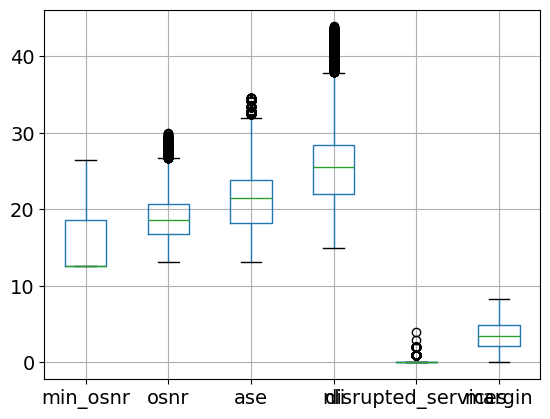

In [84]:
accepted.drop(["path_k", "path_length", "bit_rate", "modulation"], axis=1).boxplot()
plt.show()

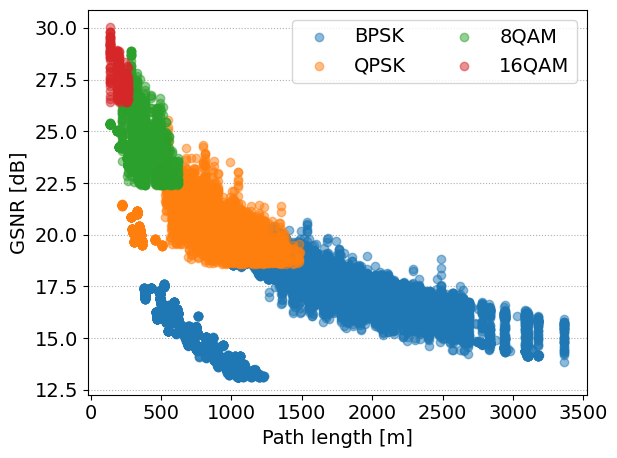

In [85]:
plt.figure()

for modulation in sorted(accepted["modulation"].unique()):
    plt.scatter(accepted[(accepted["modulation"] == modulation)]["path_length"], accepted[(accepted["modulation"] == modulation)]["osnr"], label=modulation, zorder=modulation + 1, alpha=0.5, edgecolors=None)
plt.legend(loc=0, ncols=2, labels=("BPSK", "QPSK", "8QAM", "16QAM", "32QAM", "64QAM"))
plt.xlabel("Path length [m]")
plt.ylabel("GSNR [dB]")
plt.grid(which="major", axis="y", ls=":", zorder=0)
plt.tight_layout()
# plt.savefig(f"figures/{topology_name}_lp_gsnr_length.png")
# plt.savefig(f"figures/{topology_name}_lp_gsnr_length.pdf")
# plt.savefig(f"figures/{topology_name}_lp_gsnr_length.svg")
plt.show()

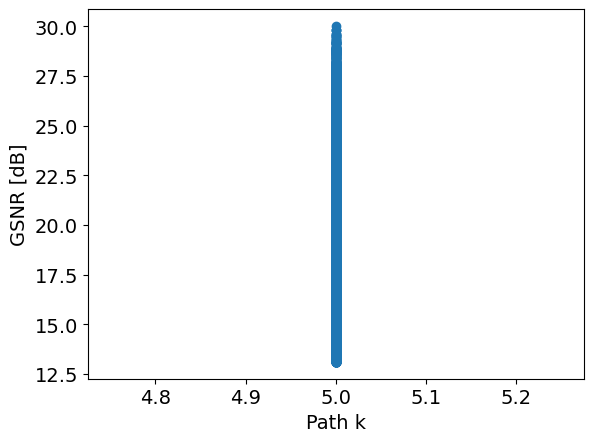

In [89]:
plt.figure()
gsnr = []
for k in range(accepted["path_k"].max()+1):
    gsnr.append(accepted[(accepted["path_k"] == k)]["osnr"].to_numpy())
plt.scatter(accepted["path_k"], accepted["osnr"])
# plt.boxplot(gsnr)
plt.xlabel("Path k")
plt.ylabel("GSNR [dB]")
plt.savefig(f"figures/{topology_name}_lp_gsnr_k_path.png")
# plt.savefig(f"figures/{topology_name}_lp_gsnr_k_path.pdf")
# plt.savefig(f"figures/{topology_name}_lp_gsnr_k_path.svg")
plt.show()

### Launch power for a certain service

## Plots for impact of margin

In [87]:
data_services = pd.read_csv(f"results/mr_services_1_0.0_{topology_name}_{best_launch_power}_{load}_10.csv", skiprows=1)
# data_services = pd.read_csv(f"results/mr_services_1_0.0_{topology_name.upper()}_-4.0_{load}_10.csv", skiprows=1)
# data_services.describe()
accepted = data_services[(data_services["path_k"] != -1)]
accepted["margin"] = accepted.apply(lambda x: x.osnr - x.min_osnr, axis=1)
# accepted = accepted.drop(["id", "source", "destination"], axis=1)
accepted.describe()

FileNotFoundError: [Errno 2] No such file or directory: 'results/mr_services_1_0.0_NOBEL-EU_-2.0_210.0_10.csv'

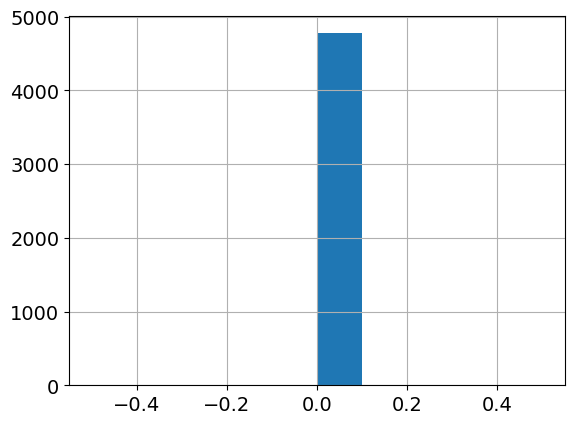

In [90]:
accepted["disrupted_services"].hist()
plt.show()

In [91]:
# data_episodes = pd.read_csv(f"results/mr_episodes_1_0.0_{topology_name.upper()}_{best_launch_power}_{load}.csv", skiprows=1)
data_episodes = pd.read_csv(f"results/mr_episodes_1_0.0_{topology_name.upper()}_-4.0_{load}.csv", skiprows=1)
data_episodes["episode_disrupted_services"]

0    0
1    0
2    0
3    0
4    0
Name: episode_disrupted_services, dtype: int64

## Plots about dataset generation

In [11]:
with open(f"results/load_episodes_{1}_{topology_name}_{int(1.0)}_{load}.pkl", "rb") as file:
    dataset = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: 'results/load_episodes_1_nobel-eu_1_210.0.pkl'

## Plots loads

In [18]:
data_loads = None
best_launch_power = 1.0
loads = np.arange(200, 1000, 100)
for strategy in strategies:
    for load in loads:
        if data_loads is None:
            data_loads = pd.read_csv(f"results/load_episodes_{strategy}_{topology_name}_{best_launch_power}_{load}.0.csv", skiprows=1)
            data_loads["strategy"] = strategy
            data_loads["load"] = load
        else:
            data_load = pd.read_csv(f"results/load_episodes_{strategy}_{topology_name}_{best_launch_power}_{load}.0.csv", skiprows=1)
            data_load["strategy"] = strategy
            data_load["load"] = load
            data_loads = pd.concat([data_loads, data_load], axis=0, ignore_index=True)
data_loads.head()

,episode,service_blocking_rate,episode_service_blocking_rate,bit_rate_blocking_rate,episode_bit_rate_blocking_rate,modulation_1,modulation_2,modulation_3,modulation_4,modulation_5,modulation_6,episode_disrupted_services,episode_time,strategy,load
0,0,0.001998,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,878.48,1,200
1,1,0.004498,0.006006,0.017230,0.017230,0.0,0.0,0.0,0.0,0.0,0.0,0.0,909.02,1,200
2,2,0.003665,0.001001,0.002859,0.002859,0.0,0.0,0.0,0.0,0.0,0.0,0.0,801.85,1,200
3,3,0.003749,0.003003,0.008688,0.008688,0.0,0.0,0.0,0.0,0.0,0.0,0.0,589.16,1,200
4,4,0.003399,0.001001,0.003172,0.003172,0.0,0.0,0.0,0.0,0.0,0.0,0.0,592.68,1,200


In [19]:
data_loads[(data_loads["strategy"] == strategy)].groupby("load").mean()

,episode,service_blocking_rate,episode_service_blocking_rate,bit_rate_blocking_rate,episode_bit_rate_blocking_rate,modulation_1,modulation_2,modulation_3,modulation_4,modulation_5,modulation_6,episode_disrupted_services,episode_time,strategy
load,,,,,,,,,,,,,,
200,2.0,0.003462,0.002202,0.006390,0.006390,0.0,0.0,0.0,0.0,0.0,0.0,0.0,754.238,1.0
300,2.0,0.016159,0.013814,0.038350,0.038350,0.0,0.0,0.0,0.0,0.0,0.0,0.0,641.860,1.0
400,2.0,0.033509,0.037037,0.106063,0.106063,0.0,0.0,0.0,0.0,0.0,0.0,0.0,596.692,1.0
500,2.0,0.052243,0.051852,0.141287,0.141287,0.0,0.0,0.0,0.0,0.0,0.0,0.0,556.942,1.0
600,2.0,0.068546,0.064665,0.176804,0.176804,0.0,0.0,0.0,0.0,0.0,0.0,0.0,531.790,1.0
700,2.0,0.072413,0.068268,0.174941,0.174941,0.0,0.0,0.0,0.0,0.0,0.0,0.0,514.562,1.0
800,2.0,0.081380,0.084885,0.214709,0.214709,0.0,0.0,0.0,0.0,0.0,0.0,0.0,504.790,1.0
900,2.0,0.104917,0.107307,0.232577,0.232577,0.0,0.0,0.0,0.0,0.0,0.0,0.0,461.500,1.0


In [1]:
plt.figure()
for ids, strategy in enumerate(strategies):
    # plt.errorbar(
    #     loads,
    #     data_loads[(data_loads["strategy"] == strategy)].groupby("load").mean()["episode_service_blocking_rate"],
    #     data_loads[(data_loads["strategy"] == strategy)].groupby("load").std()["episode_service_blocking_rate"],
    #     label=strategy, #marker="x"
    # )
    plt.plot(
        loads,
        data_loads[(data_loads["strategy"] == strategy)].groupby("load").mean()["episode_service_blocking_rate"],
        # data_loads[(data_loads["strategy"] == strategy)].groupby("load").std()["episode_service_blocking_rate"],
        label=strategy,
        marker=markers[ids],
        mec="white",
    )
    # print(strategy, data_loads[(data_loads["strategy"] == strategy)].groupby("load").mean()["episode_service_blocking_rate"])

plt.xlabel("Load [Erlang]")
plt.ylabel("Request blocking rate")
plt.gca().set_yscale("log")
plt.grid(visible=True, which="major", axis="y", ls="--")
plt.grid(visible=True, which="minor", axis="y", ls=":")
plt.legend(labels=heuristics)
plt.tight_layout()
plt.savefig(f"figures/{topology_name}_load_rbr.png")
plt.savefig(f"figures/{topology_name}_load_rbr.pdf")
# plt.savefig(f"figures/{topology_name}_load_rbr.svg")
plt.show()

NameError: name 'plt' is not defined

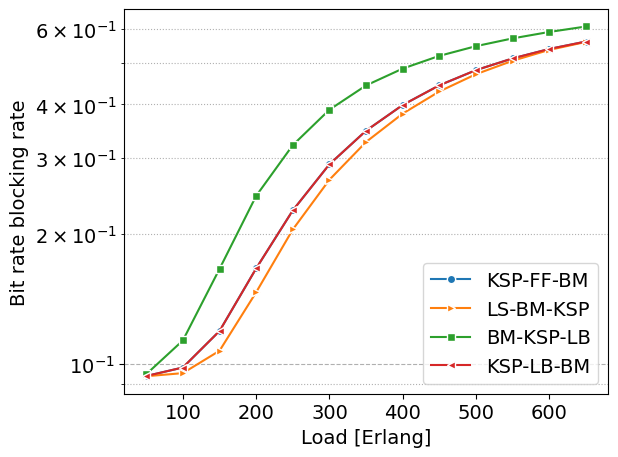

In [70]:
plt.figure()
for ids, strategy in enumerate(strategies):
    plt.plot(
        # loads,
        data_loads[(data_loads["strategy"] == strategy)].groupby("load").mean()["episode_bit_rate_blocking_rate"],
        # data_loads[(data_loads["strategy"] == strategy)].groupby("load").std()["episode_bit_rate_blocking_rate"],
        label=strategy,
        marker=markers[ids],
        mec="white",
    )

plt.xlabel("Load [Erlang]")
plt.ylabel("Bit rate blocking rate")
plt.gca().set_yscale("log")
plt.grid(visible=True, which="major", axis="y", ls="--")
plt.grid(visible=True, which="minor", axis="y", ls=":")
plt.legend(labels=heuristics)
plt.tight_layout()
plt.savefig(f"figures/{topology_name}_load_brbr.png")
plt.savefig(f"figures/{topology_name}_load_brbr.pdf")
# plt.savefig(f"figures/{topology_name}_load_brbr.svg")
plt.show()

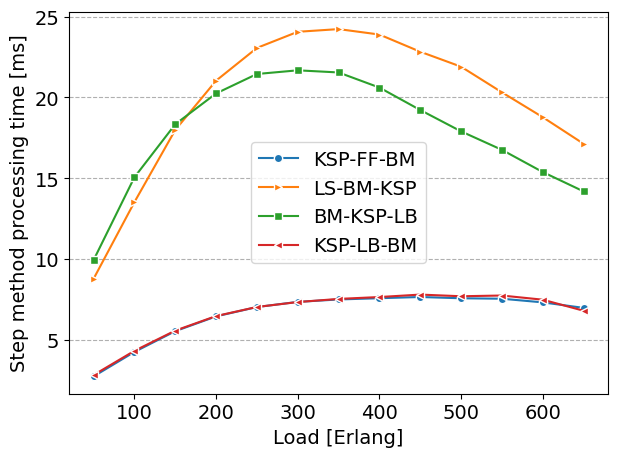

In [71]:
plt.figure()
for ids, strategy in enumerate(strategies):
    # plt.errorbar(
    #     loads,
    #     data_loads[(data_loads["strategy"] == strategy)].groupby("load").mean()["episode_service_blocking_rate"],
    #     data_loads[(data_loads["strategy"] == strategy)].groupby("load").std()["episode_service_blocking_rate"],
    #     label=strategy, #marker="x"
    # )
    plt.plot(
        loads,
        data_loads[(data_loads["strategy"] == strategy)].groupby("load").mean()["episode_time"],
        # data_loads[(data_loads["strategy"] == strategy)].groupby("load").std()["episode_service_blocking_rate"],
        label=strategy,
        marker=markers[ids],
        mec="white",
    )
    # print(strategy, data_loads[(data_loads["strategy"] == strategy)].groupby("load").mean()["episode_service_blocking_rate"])

plt.xlabel("Load [Erlang]")
plt.ylabel("Step method processing time [ms]")
# plt.gca().set_yscale("log")
plt.grid(visible=True, which="major", axis="y", ls="--")
plt.grid(visible=True, which="minor", axis="y", ls=":")
plt.legend(labels=heuristics)
plt.tight_layout()
plt.savefig(f"figures/{topology_name}_load_step_time.png")
plt.savefig(f"figures/{topology_name}_load_step_time.pdf")
# plt.savefig(f"figures/{topology_name}_load_rbr.svg")
plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data_loads = None
best_launch_power = 1.0
loads = np.arange(50, 300, 50)
topology_name = "nobel-eu"
for strategy in [1,2]:
    for load in loads:
        for defragmentation in [[False,0], [True, 10], [True, 0]]:
            if data_loads is None:
                data_loads = pd.read_csv(f"results/load_episodes_{strategy}_def_{defragmentation[0]}_{defragmentation[1]}_{topology_name}_{best_launch_power}_{load}.0.csv", skiprows=1)
                print(f"results/load_episodes_{strategy}_def_{defragmentation[0]}_{defragmentation[1]}_{topology_name}_{best_launch_power}_{load}.0.csv")
                data_loads["strategy"] = strategy
                data_loads["load"] = load
                data_loads["defragmentation"] = defragmentation[0]
                data_loads["defragmentation_steps"] = defragmentation[1]
            else:
                data_load = pd.read_csv(f"results/load_episodes_{strategy}_def_{defragmentation[0]}_{defragmentation[1]}_{topology_name}_{best_launch_power}_{load}.0.csv", skiprows=1)
                data_load["strategy"] = strategy
                data_load["load"] = load
                data_load["defragmentation"] = defragmentation[0]
                data_load["defragmentation_steps"] = defragmentation[1]
                data_loads = pd.concat([data_loads, data_load], axis=0, ignore_index=True)

data_loads.head()

results/load_episodes_1_def_False_0_nobel-eu_1.0_50.0.csv


,episode,service_blocking_rate,episode_service_blocking_rate,bit_rate_blocking_rate,episode_bit_rate_blocking_rate,episode_service_realocations,episode_defrag_cicles,modulation_1,modulation_2,modulation_3,modulation_4,modulation_5,modulation_6,episode_disrupted_services,episode_time,mean_gsnr,strategy,load,defragmentation,defragmentation_steps
0,0,0.001998,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,958.36,18.473243,1,50,False,0
1,1,0.001499,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,951.51,18.461338,1,50,False,0
2,2,0.001333,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,932.89,18.399193,1,50,False,0
3,0,0.001998,0.0,0.0,0.0,736,109,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1036.41,18.255225,1,50,True,10
4,1,0.001499,0.0,0.0,0.0,553,82,0.0,0.0,0.0,0.0,0.0,0.0,0.0,979.31,18.393049,1,50,True,10


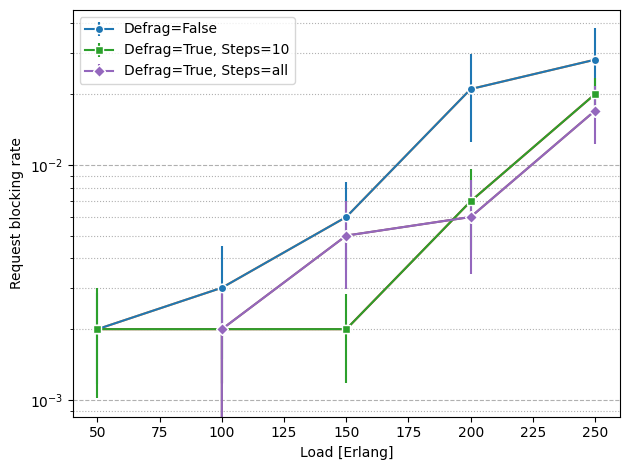

In [13]:
plt.figure()

data_loads.loc[(data_loads["defragmentation"] == True) & (data_loads["defragmentation_steps"] == 0), "defragmentation_steps"] = "all"
data_loads.loc[(data_loads["defragmentation"] == False), "defragmentation_steps"] = ""

# Obter as combinações únicas de defragmentation e defragmentation_steps
unique_combinations = data_loads[['defragmentation', 'defragmentation_steps']].drop_duplicates().reset_index(drop=True)

# Defina uma lista de marcadores (ou use outro esquema de diferenciação, como cores ou estilos de linha)
markers = ['o', 's', 'D', 'x', '^', 'v']

# Iterar sobre cada combinação única
for idx, row in unique_combinations.iterrows():
    defrag = row['defragmentation']
    steps  = row['defragmentation_steps']
    
    # Filtrar os dados para a combinação atual
    df_filtered = data_loads[(data_loads['defragmentation'] == defrag) & (data_loads['defragmentation_steps'] == steps)]
    
    # Agrupar por 'load' e calcular a média e o desvio padrão
    grouped = df_filtered.groupby("load")["episode_service_blocking_rate"]
    mean_vals = grouped.max()
    std_vals = grouped.std()
    
    # Cria um label informativo para a combinação, sem exibir steps quando defrag == False
    if not defrag:
        label = f"Defrag={defrag}"
    else:
        label = f"Defrag={defrag}, Steps={steps}"
    
    # Plotar a linha com barras de erro
    plt.errorbar(
        mean_vals.index,
        mean_vals,
        yerr=std_vals,
        label=label,
        marker=markers[idx % len(markers)],
        linestyle='-',  # pode ajustar se preferir outro estilo
        mec="white"
    )
    
    # Opcional: também pode plotar a linha sem as barras de erro para reforçar o visual
    plt.plot(
        mean_vals.index,
        mean_vals,
        marker=markers[idx % len(markers)],
        linestyle='-',
        mec="white"
    )

plt.xlabel("Load [Erlang]")
plt.ylabel("Request blocking rate")
plt.gca().set_yscale("log")
plt.grid(visible=True, which="major", axis="y", ls="--")
plt.grid(visible=True, which="minor", axis="y", ls=":")
plt.legend()
plt.tight_layout()
# plt.savefig(f"figures/{topology_name}_load_rbr.png")
# plt.savefig(f"figures/{topology_name}_load_rbr.pdf")
plt.show()


C:\Users\talle\AppData\Local\Temp\ipykernel_940\3282881790.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results = results.fillna(0).astype(int)


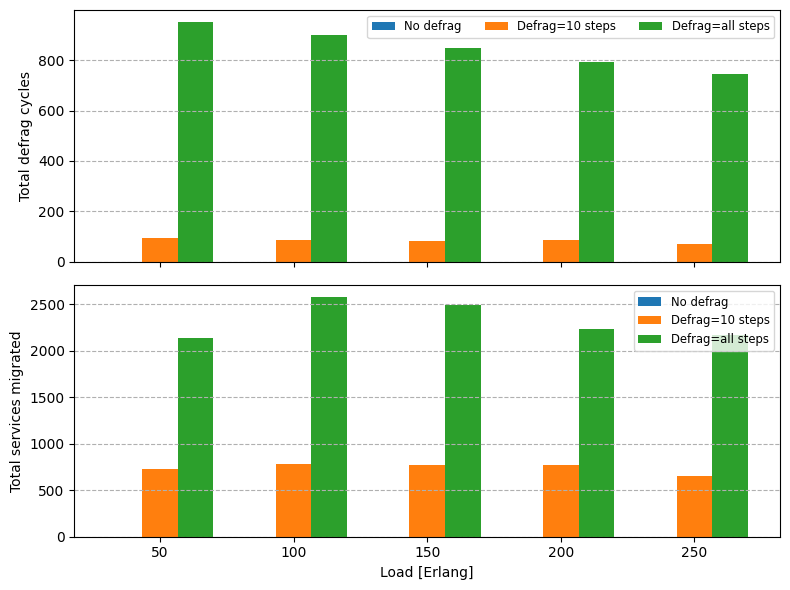

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Prepara os steps conforme você já faz ---
data_loads.loc[
    (data_loads["defragmentation"] == True) & (data_loads["defragmentation_steps"] == 0),
    "defragmentation_steps"
] = "all"
data_loads.loc[
    (data_loads["defragmentation"] == False),
    "defragmentation_steps"
] = ""

# --- 2) Definição das estratégias ---
strategies = {
    "No defrag":          (data_loads["defragmentation"] == False),
    "Defrag=10 steps":    (data_loads["defragmentation"] == True) & (data_loads["defragmentation_steps"] == 10),
    "Defrag=all steps":   (data_loads["defragmentation"] == True) & (data_loads["defragmentation_steps"] == "all"),
}

# --- 3) Lista de cargas ---
loads = sorted(data_loads["load"].unique())

# --- 4) Monta DataFrame de resultados ---
results = pd.DataFrame(index=loads, columns=pd.MultiIndex.from_product(
    [strategies.keys(), ["calls", "migrated"]]
))

for strat_name, condition in strategies.items():
    df_strat = data_loads[condition]
    for load in loads:
        df_sub = df_strat[df_strat["load"] == load]
        # Se quiser contar quantos episódios executaram defrag:
        # calls = (df_sub["episode_defrag_cicles"] > 0).sum()
        # Se quiser somar o total de ciclos de defrag:
        calls = df_sub[' episode_defrag_cicles'].mean()
        migrated = df_sub[" episode_service_realocations"].mean()
        results.loc[load, (strat_name, "calls")] = calls
        results.loc[load, (strat_name, "migrated")] = migrated

# Converte para numérico
results = results.fillna(0).astype(int)

# --- 5) Plot ---
n_loads = len(loads)
n_strat = len(strategies)
bar_width = 0.8 / n_strat  # distribuir dentro de 0.8 do tick

x = np.arange(n_loads)
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

for i, metric in enumerate(["calls", "migrated"]):
    ax = axes[i]
    for j, strat_name in enumerate(strategies.keys()):
        vals = results[(strat_name, metric)].values
        offset = (j - (n_strat-1)/2) * bar_width
        ax.bar(
            x + offset,
            vals,
            width=bar_width,
            label=strat_name,
            capsize=3
        )
    ax.set_ylabel("Total " + ("defrag cycles" if metric=="calls" else "services migrated"))
    ax.grid(visible=True, which="major", axis="y", ls="--")
    ax.legend(ncol=3 if i==0 else 1, fontsize='small')

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(loads)
axes[-1].set_xlabel("Load [Erlang]")
plt.tight_layout()
plt.show()



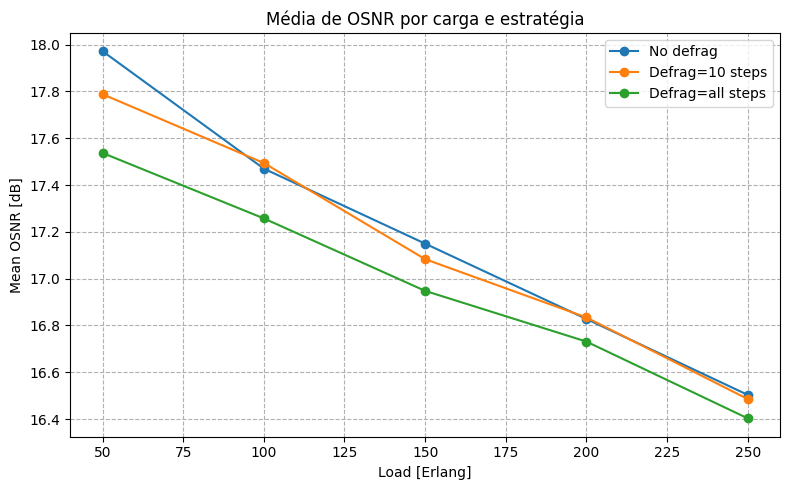

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Prepara os steps conforme antes ---
data_loads.loc[
    (data_loads["defragmentation"] == True) & (data_loads["defragmentation_steps"] == 0),
    "defragmentation_steps"
] = "all"
data_loads.loc[
    (data_loads["defragmentation"] == False),
    "defragmentation_steps"
] = ""

# --- 2) Definição das estratégias ---
strategies = {
    "No defrag":          (data_loads["defragmentation"] == False),
    "Defrag=10 steps":    (data_loads["defragmentation"] == True) & (data_loads["defragmentation_steps"] == 10),
    "Defrag=all steps":   (data_loads["defragmentation"] == True) & (data_loads["defragmentation_steps"] == "all"),
}

# --- 3) Lista de cargas ---
loads = sorted(data_loads["load"].unique())

# --- 4) Calcula média de OSNR por carga e estratégia ---
osnr_means = pd.DataFrame(index=loads, columns=strategies.keys(), dtype=float)

for strat_name, condition in strategies.items():
    df_strat = data_loads[condition]
    # agrupa por load e calcula média de mean_gsnr
    grp = df_strat.groupby("load")["mean_gsnr"].mean()
    # reindex para garantir todas as cargas
    osnr_means[strat_name] = grp.reindex(loads, fill_value=0)

# --- 5) Plot de linhas ---
fig, ax = plt.subplots(figsize=(8, 5))

for strat_name in strategies.keys():
    ax.plot(
        loads,
        osnr_means[strat_name],
        marker='o',
        linestyle='-',
        label=strat_name
    )

ax.set_xlabel("Load [Erlang]")
ax.set_ylabel("Mean OSNR [dB]")
ax.set_title("Média de OSNR por carga e estratégia")
ax.grid(visible=True, which="major", axis="both", ls="--")
ax.legend()
plt.tight_layout()
plt.show()
